In [9]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

In [ ]:
years = [2021.0, 2022.0, 2023.0]
boroughs = ['manhattan', 'brooklyn', 'bronx', 'queens']

borough_year_data = {}
for y in years:
    borough_year_data[y] = {}
    for b in boroughs:
        borough_year_data[y][b] = pd.read_csv(f"..\\Dataset\\NYC_DWT_Analysis\\{y}\\{b}.csv")

nta_gdf = gpd.read_file("..\\Dataset\\NYC_DWT_Analysis\\nynta2020_25d\\nynta2020.shp")
nta_gdf['NTA2020'] = nta_gdf["NTA2020"].astype(str).str.lower()

In [11]:
#NTA aggregation, just as before
nta_data = {}
for y in years:
    nta_data[y] = {}
    for b in boroughs:
        df = borough_year_data[y][b].copy()

        df["has_violation"] = (df["Violation_Code"] != '0').astype(int)
        df["is_audit"] = (df["Activity_Type"] == "nyc health department audit").astype(int)

        agg = df.groupby('NTA_Code').agg(   inspection_count = ("BIN", "count"),
                                            violation_count = ("has_violation", "sum"),
                                            total_dwt = ('Number of DWT', "sum"),
                                            audit_count = ("is_audit", "sum"), ).reset_index()

        agg["violation_rate"] = agg["violation_count"]/agg["inspection_count"]
        agg["avg_dwt"]        = agg["total_dwt"]/agg["inspection_count"]
        agg["audit_fraction"] = agg["audit_count"]/agg["inspection_count"]

        nta_data[y][b] = agg.drop(columns=["violation_count", "total_dwt", "audit_count"])

In [12]:
NTA_Prefix = {'bronx': 'bx', 'queens': 'qn', 'brooklyn': 'bk', 'manhattan': 'mn'}

geo_data = {}
for y in years:
    geo_data[y] = {}
    for b in boroughs:
        prefix = NTA_Prefix[b]
        borough_shape = nta_gdf[nta_gdf["NTA2020"].str.startswith(prefix)].copy()
        merged = borough_shape.merge(nta_data[y][b], left_on="NTA2020", right_on="NTA_Code", how="left")
        for col in ["inspection_count", "violation_rate", "avg_dwt", "audit_fraction"]:
            merged[col] = merged[col].fillna(0)
        geo_data[y][b] = merged.reset_index(drop=True)

In [ ]:
#Cleaning the data
def remove_outlier_coords(pts, z_thresh=3.0):
    if len(pts) < 4:
        return pts
    median = np.median(pts, axis=0)
    mad = np.median(np.abs(pts - median), axis=0)
    robust_std = mad * 1.4826 + 1e-9
    z_scores = np.abs(pts - median) / robust_std
    return pts[np.all(z_scores < z_thresh, axis=1)]

In [14]:
#Calculating the optimal bandwidth using h = 0.9 * spread * n_points ** (-0.2)
def calculate_optimal_blur(coords):
    n_points = len(coords)
    if n_points < 2:
        return 0.01
    spread = 0.5 * (np.std(coords[:, 0]) + np.std(coords[:, 1]))
    h = 0.9 * spread * n_points ** (-0.2)
    return float(np.clip(h, 0.005, 0.05))

In [ ]:
#Generating a density surface over the map
def create_density_surface(pts, bandwidth, bbox, resolution=120):
    x_min, x_max, y_min, y_max = bbox
    grid_x = np.linspace(x_min, x_max, resolution)
    grid_y = np.linspace(y_min, y_max, resolution)

    mesh_x, mesh_y = np.meshgrid(grid_x, grid_y)
    grid_points = np.c_[mesh_x.ravel(), mesh_y.ravel()]
    
    dist_sq = cdist(grid_points, pts, "sqeuclidean")
    kernel = np.exp(-0.5 * dist_sq / bandwidth**2)
    density = kernel.sum(axis=1) / (len(pts) * 2 * np.pi * bandwidth**2)
    return mesh_x, mesh_y, density.reshape(mesh_x.shape)

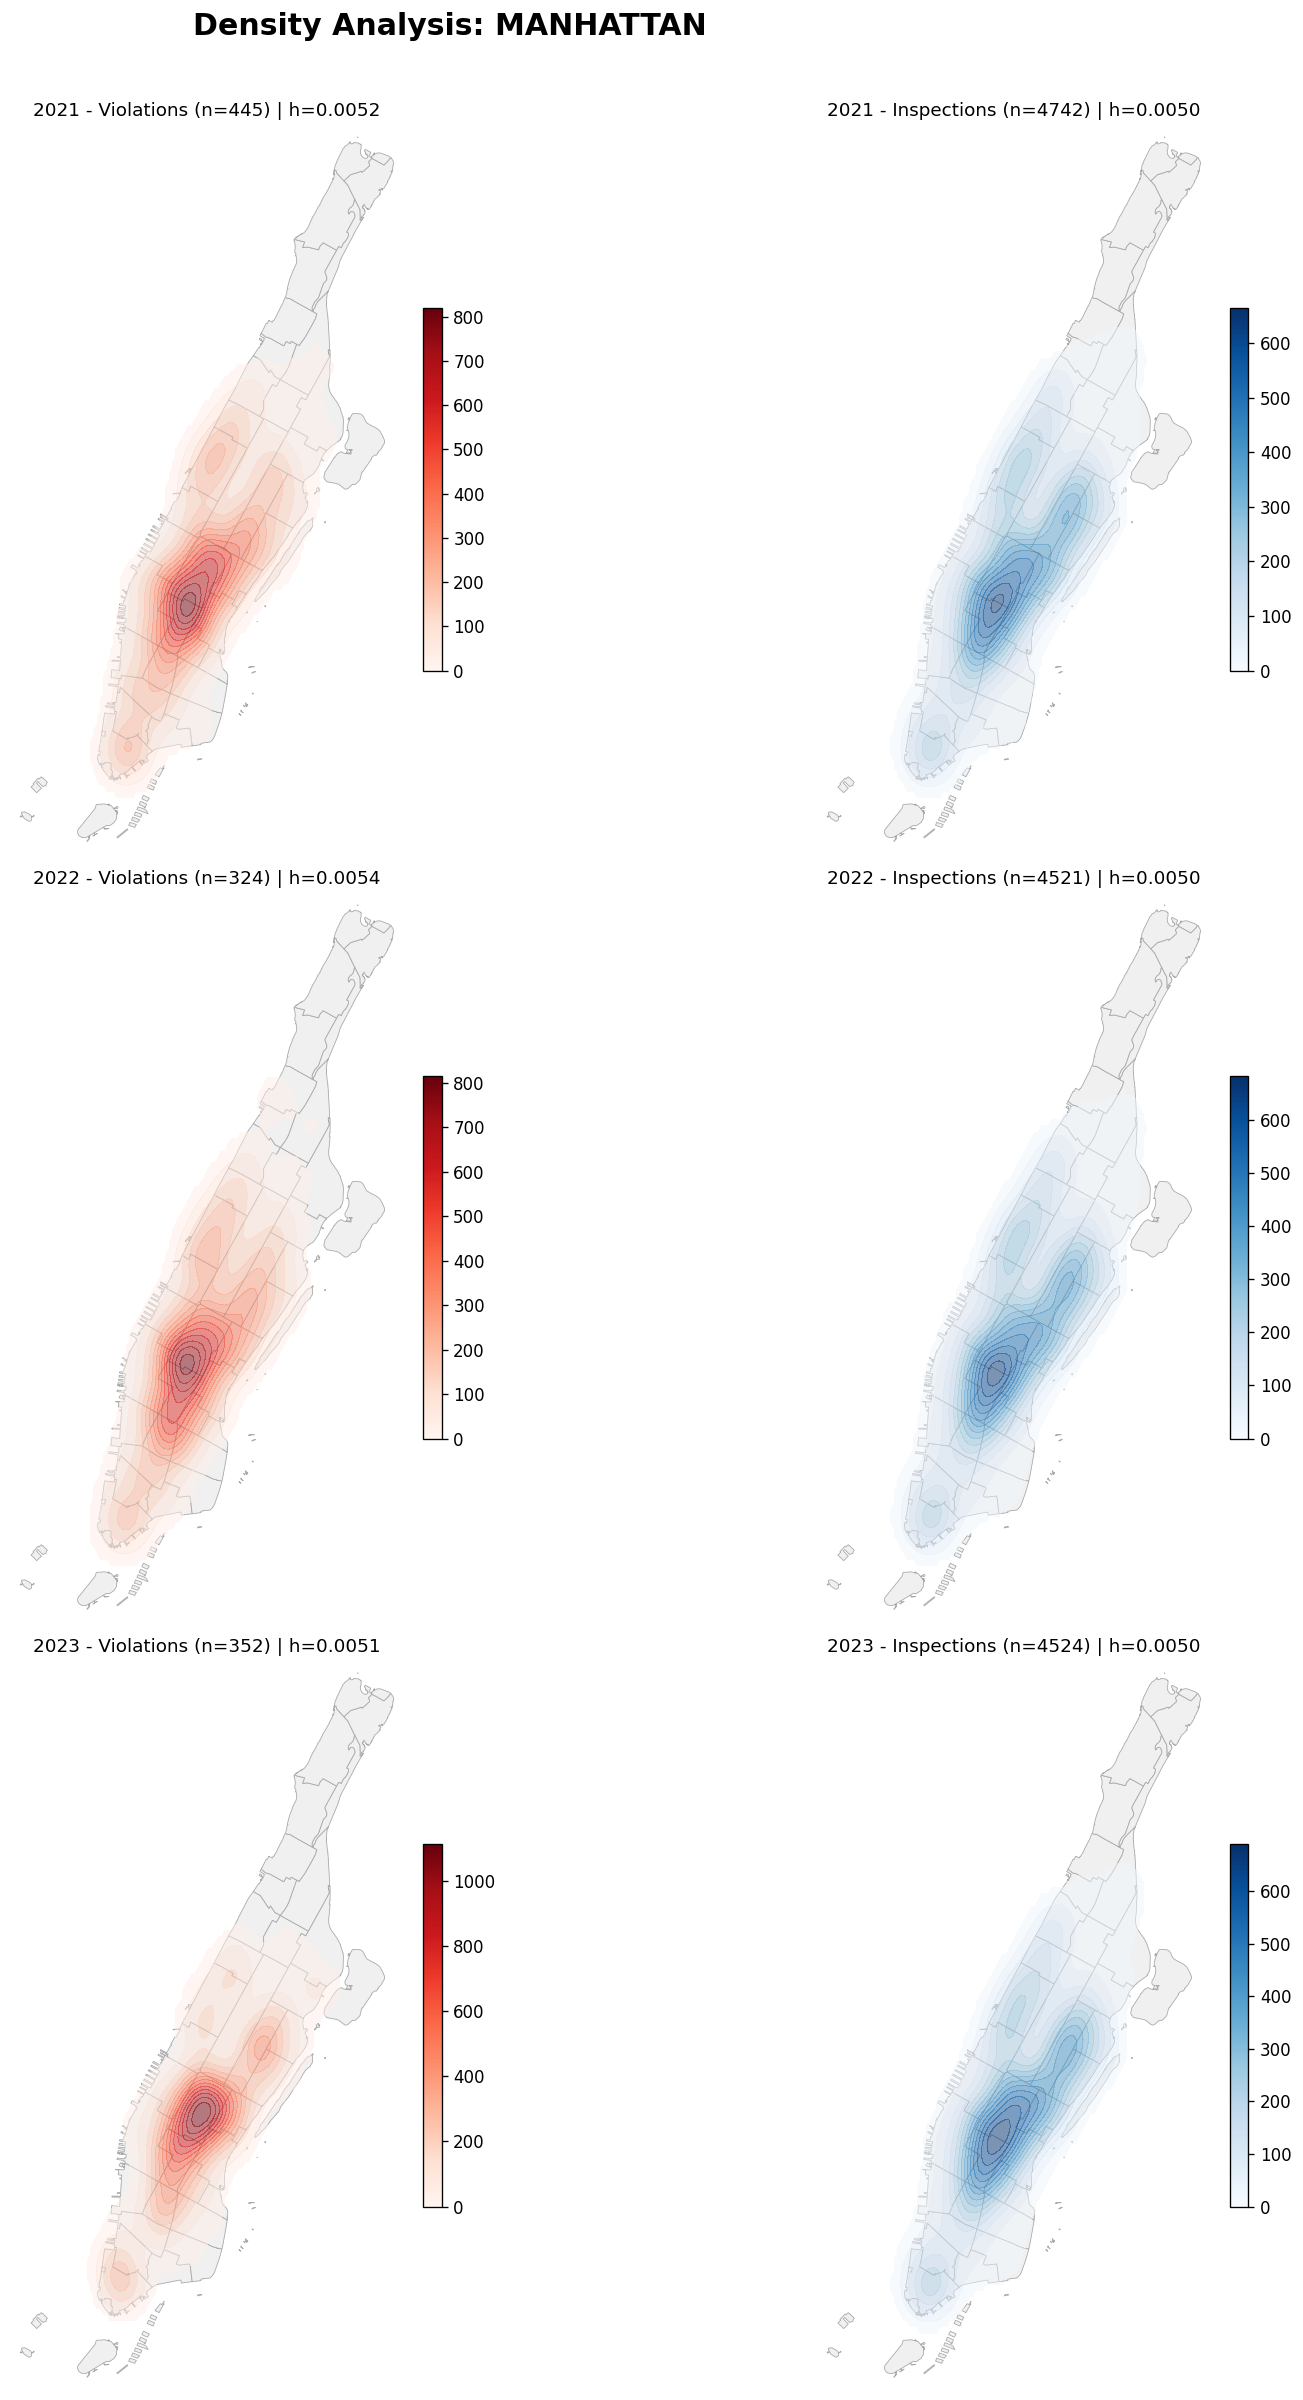

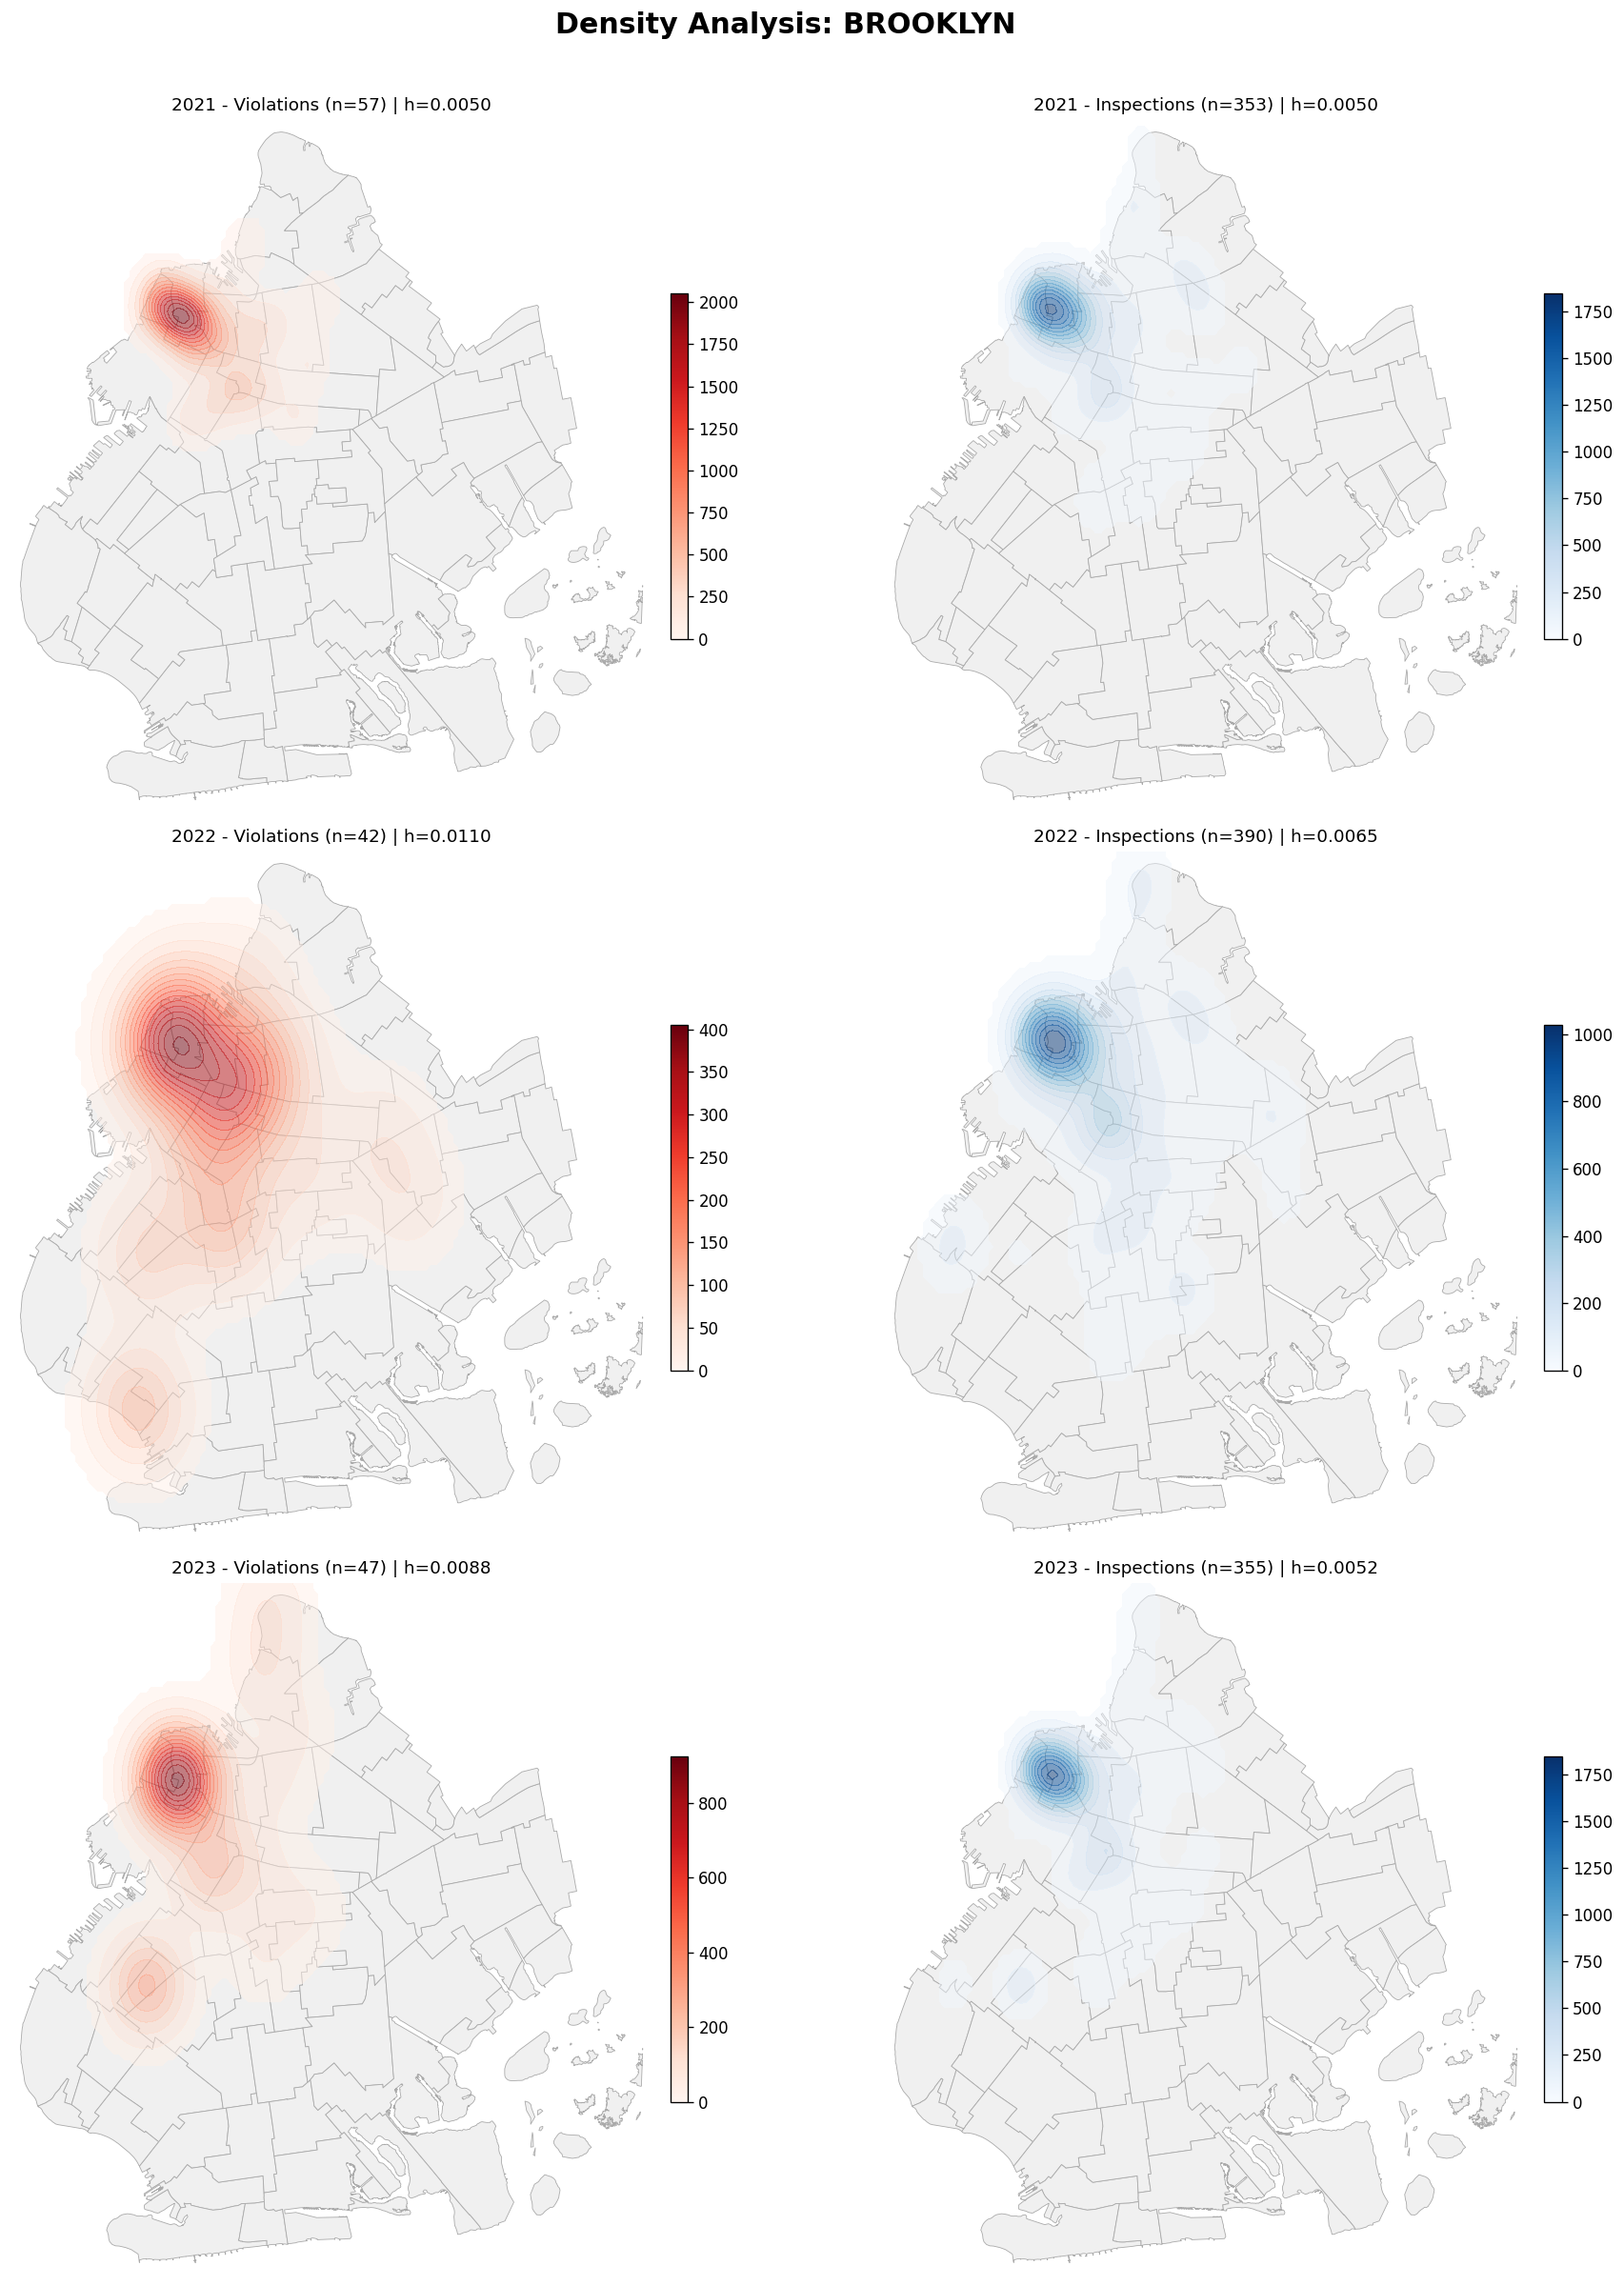

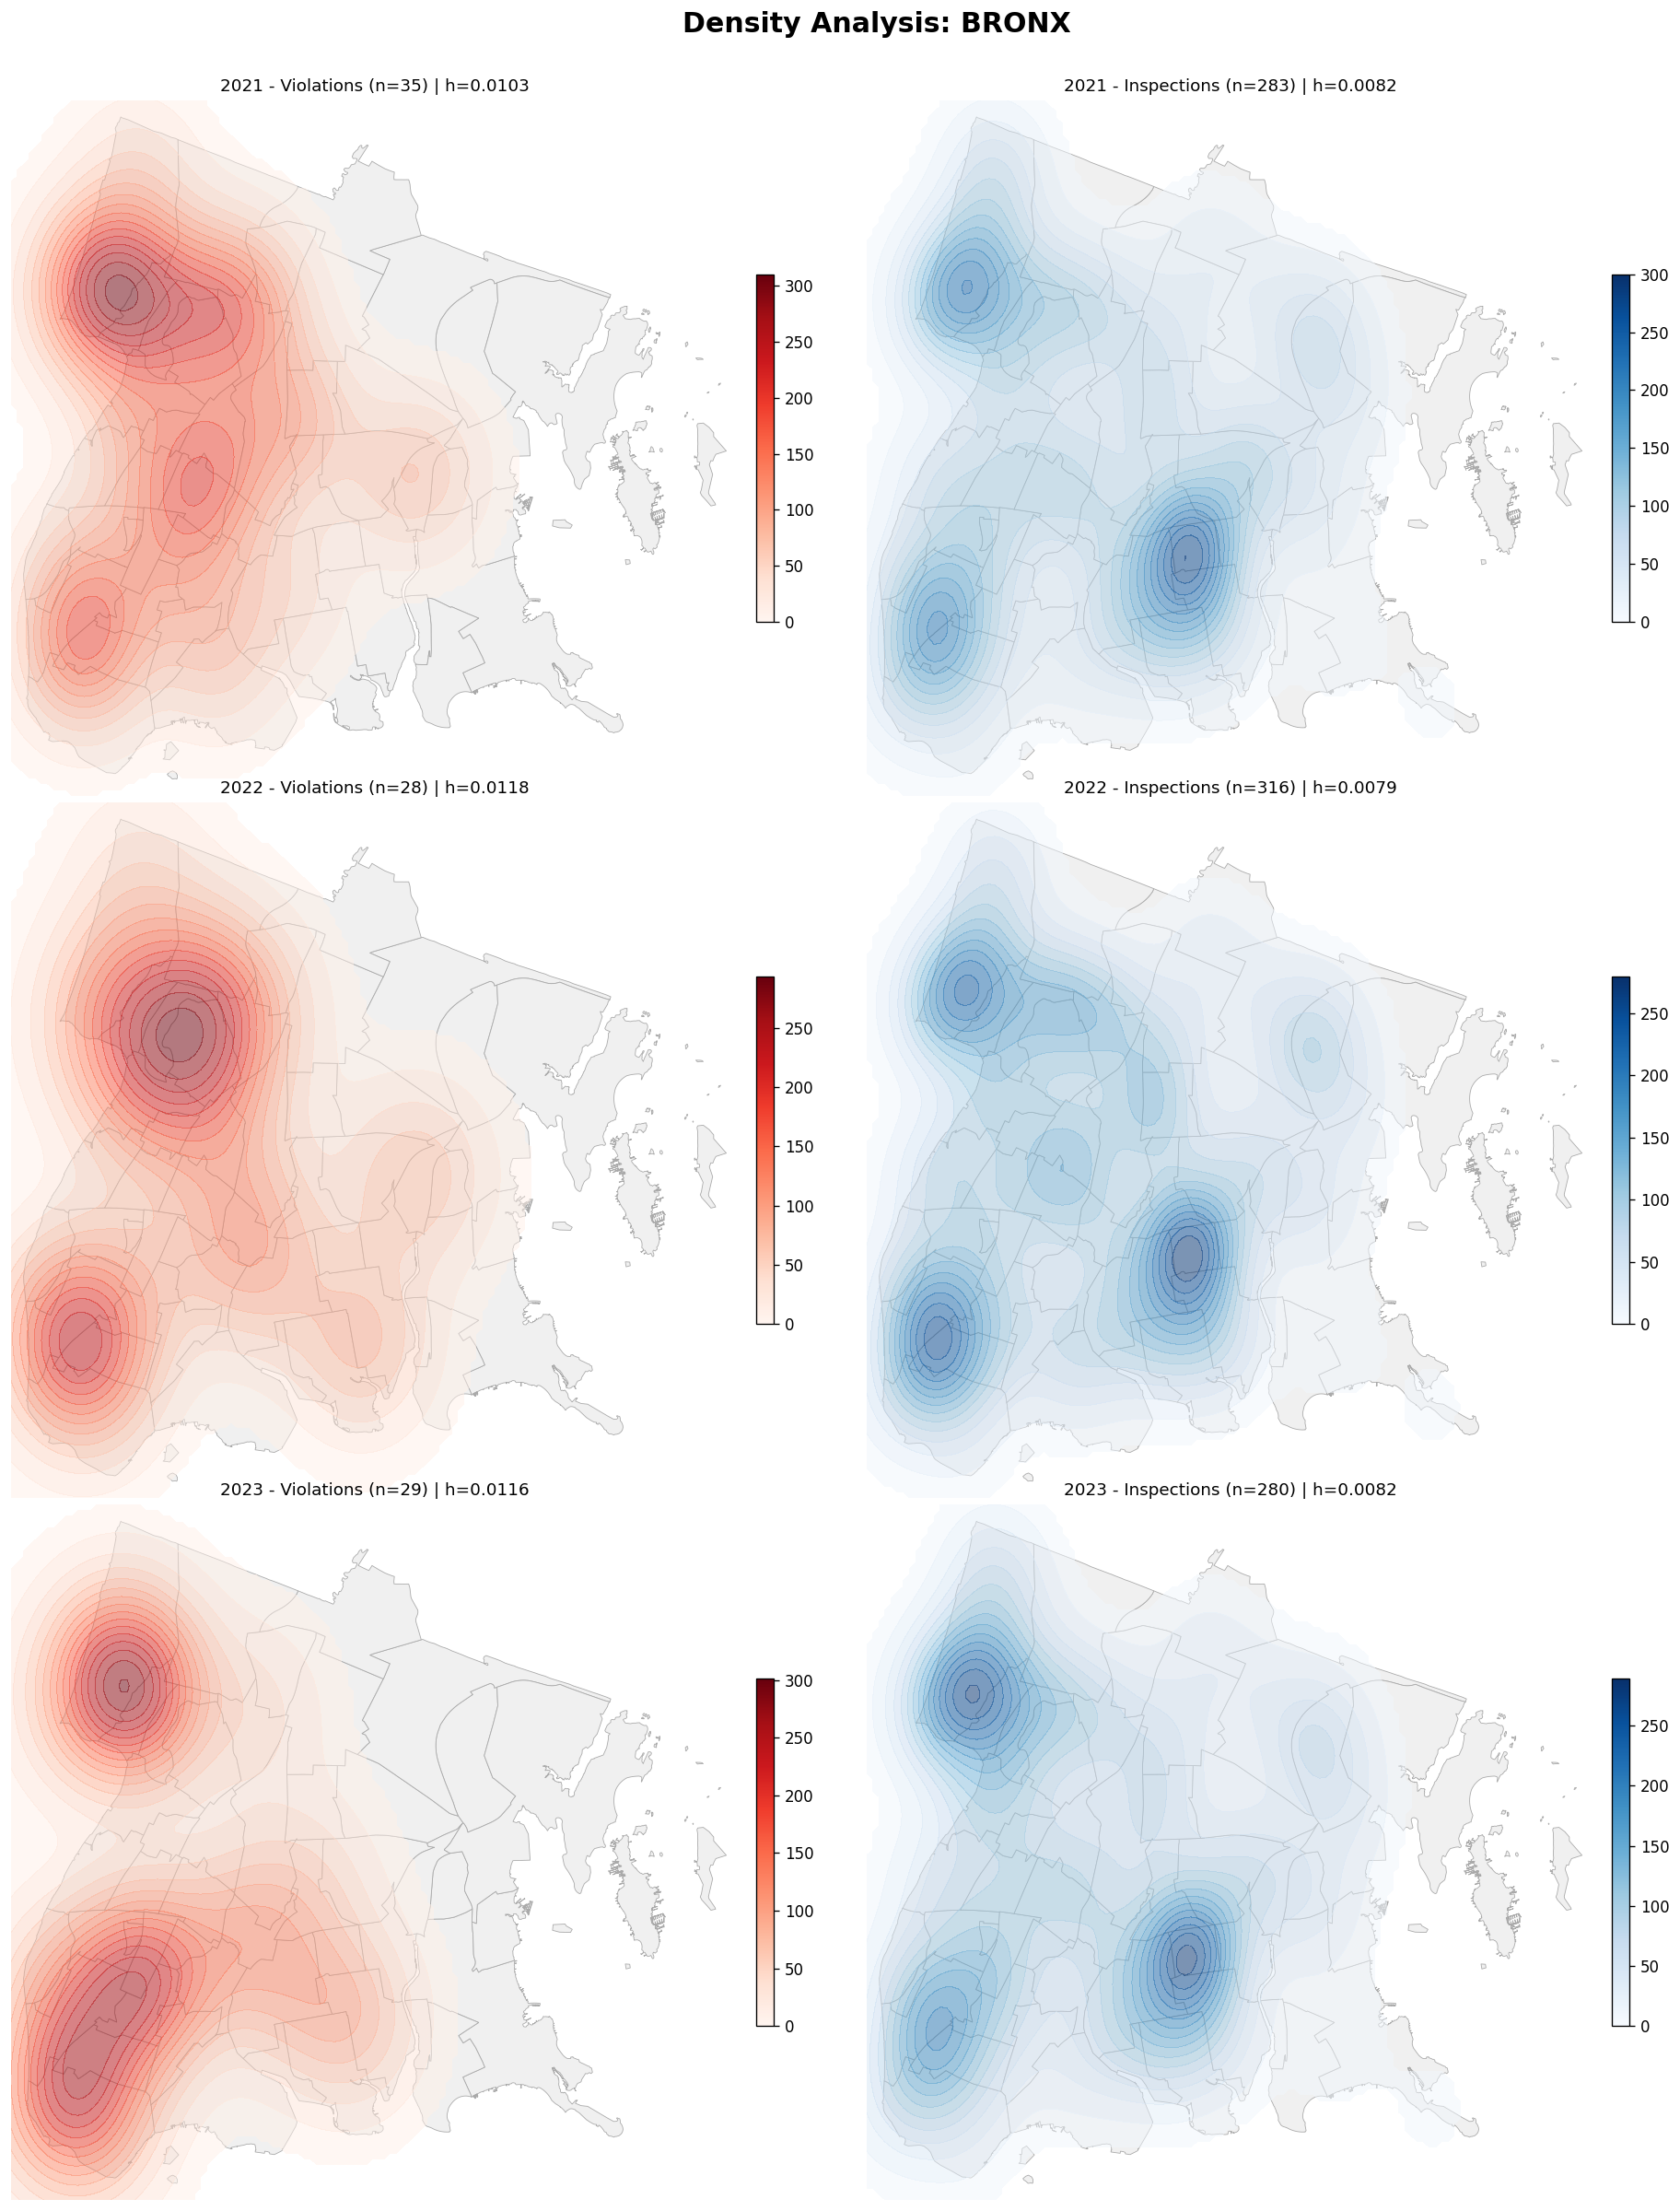

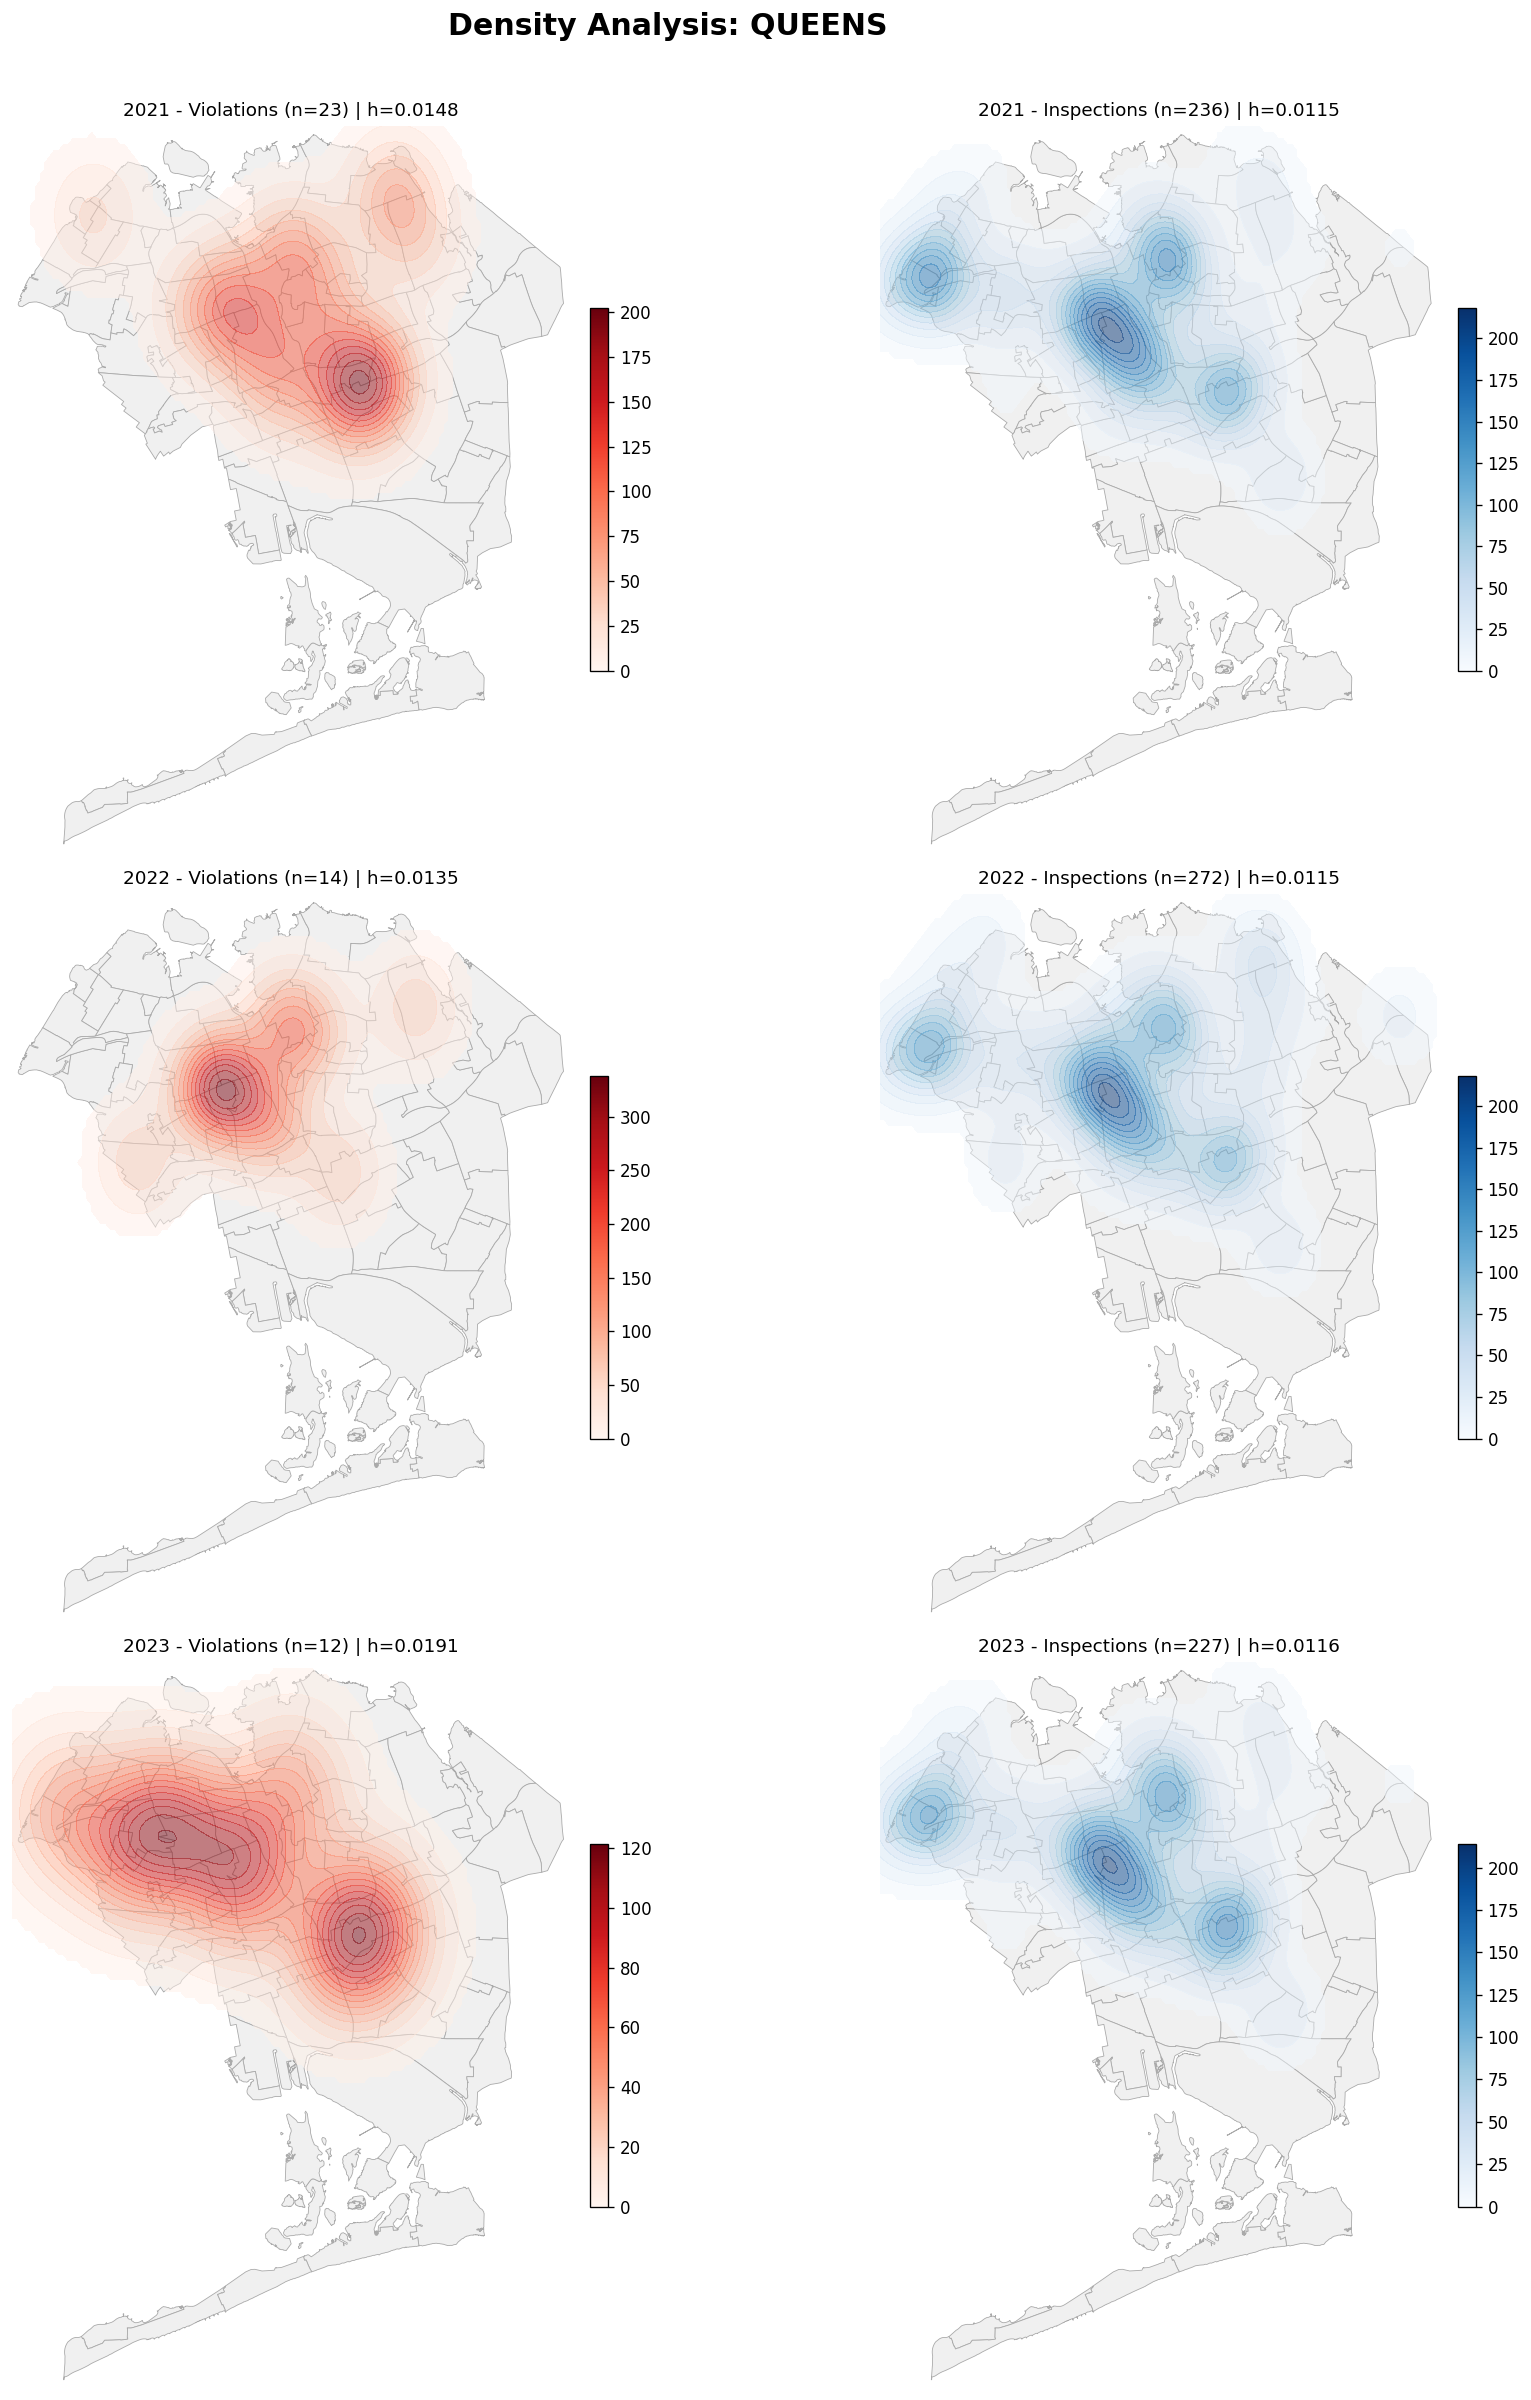

In [ ]:
for b in boroughs:
    fig, axes = plt.subplots(len(years), 2, figsize=(16, 7 * len(years)), dpi=120)
    fig.suptitle(f"Density Analysis: {b.upper()}", fontsize=18, fontweight='bold', y=0.98)

    for yi, y in enumerate(years):
        df_raw = borough_year_data[y][b].copy()
        df_raw[["Longitude", "Latitude"]] = df_raw[["Longitude", "Latitude"]].apply(pd.to_numeric, errors="coerce")
        df_raw = df_raw.dropna(subset=["Longitude", "Latitude"])

        df_viol = df_raw[df_raw["Violation_Code"] != "0"]
        views = [(df_viol, "Violations", "Reds"), (df_raw, "Inspections", "Blues")]

        for ci, (df_pts, label, cmap) in enumerate(views):
            ax = axes[yi, ci]

            pts_raw = np.c_[df_pts.Longitude.values, df_pts.Latitude.values]

            pts = remove_outlier_coords(pts_raw)
            if len(pts) >= 10:
                margin = 0.003
                bbox = (pts[:, 0].min() - margin, pts[:, 0].max() + margin,
                        pts[:, 1].min() - margin, pts[:, 1].max() + margin)

                gdf_base = geo_data[y][b]
                if gdf_base.crs and gdf_base.crs.to_epsg() != 4326:
                    gdf_base = gdf_base.to_crs(epsg=4326)
                bx_min, by_min, bx_max, by_max = gdf_base.total_bounds
                bbox = (bx_min - margin, bx_max + margin, by_min - margin, by_max + margin)
                gdf_base.plot(ax=ax, color="#f0f0f0", edgecolor="#aaaaaa", linewidth=0.5, zorder=1)

                h = calculate_optimal_blur(pts)
                xx, yy, Z = create_density_surface(pts, h, bbox)

                Z_plot = np.where(Z > Z.max() * 0.02, Z, np.nan)

                cf = ax.contourf(xx, yy, Z_plot, levels=15, cmap=cmap, alpha=0.5, zorder=2)
                ax.set_title(f"{int(y)} - {label} (n={len(df_pts)}) | h={h:.4f}", fontsize=11)

                ax.set_xlim(bbox[0], bbox[1])
                ax.set_ylim(bbox[2], bbox[3])

                sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=Z.max()))
                plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
                ax.set_xlim(bbox[0], bbox[1])
                ax.set_ylim(bbox[2], bbox[3])

            else:
                ax.set_title(f"{int(y)} - {label} (Insufficient Data)", fontsize=11)

            ax.set_axis_off()

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()